## โหลดข้อมูล


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin-1')

print(f"จำนวนแถว (orders): {df.shape[0]:,}")
print(f"จำนวนคอลัมน์ (features): {df.shape[1]}")


จำนวนแถว (orders): 9,994
จำนวนคอลัมน์ (features): 21


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Row ID          9994 non-null   int64   
 1   Order ID        9994 non-null   object  
 2   Order Date      9994 non-null   object  
 3   Ship Date       9994 non-null   object  
 4   Ship Mode       9994 non-null   object  
 5   Customer ID     9994 non-null   object  
 6   Customer Name   9994 non-null   object  
 7   Segment         9994 non-null   object  
 8   Country         9994 non-null   object  
 9   City            9994 non-null   object  
 10  State           9994 non-null   object  
 11  Postal Code     9994 non-null   int64   
 12  Region          9994 non-null   object  
 13  Product ID      9994 non-null   object  
 14  Category        9994 non-null   object  
 15  Sub-Category    9994 non-null   object  
 16  Product Name    9994 non-null   object  
 17  Sales         


## เช็ค Missing Values


In [ ]:
missing = df.isnull().sum()
print("จำนวน missing values แต่ละคอลัมน์:")
print(missing[missing > 0] if missing.any() else "ไม่มี missing values เลย!")
print(f"\nจำนวนแถวซ้ำ (duplicates): {df.duplicated().sum()}")

จำนวน missing values แต่ละคอลัมน์:
ไม่มี missing values เลย!

จำนวนแถวซ้ำ (duplicates): 0



## วิเคราะห์ Profit


In [ ]:
print(f"ค่าเฉลี่ย (mean):$ {df['Profit'].mean():.2f}")
print(f"ค่ากลาง (median):$ {df['Profit'].median():.2f}")
print(f"ค่าต่ำสุด (min):$ {df['Profit'].min():.2f}")
print(f"ค่าสูงสุด (max):$ {df['Profit'].max():.2f}")
print()

profit_count = (df['Profit'] >= 0).sum()
loss_count = (df['Profit'] < 0).sum()
print(f"Order ที่กำไร: {profit_count:,} ตัว ({profit_count/len(df)*100:.1f}%)")
print(f"Order ที่ขาดทุน: {loss_count:,} ตัว ({loss_count/len(df)*100:.1f}%)")
print()

print(f"รวมกำไรทั้งหมด: ${df[df['Profit']>=0]['Profit'].sum():,.0f}")
print(f"รวมขาดทุนทั้งหมด: ${df[df['Profit']<0]['Profit'].sum():,.0f}")

ค่าเฉลี่ย (mean):$ 28.66
ค่ากลาง (median):$ 8.67
ค่าต่ำสุด (min):$ -6599.98
ค่าสูงสุด (max):$ 8399.98

Order ที่กำไร: 8,123 ตัว (81.3%)
Order ที่ขาดทุน: 1,871 ตัว (18.7%)

รวมกำไรทั้งหมด: $442,528
รวมขาดทุนทั้งหมด: $-156,131


## ความสัมพันธ์ Discount กับ Profit

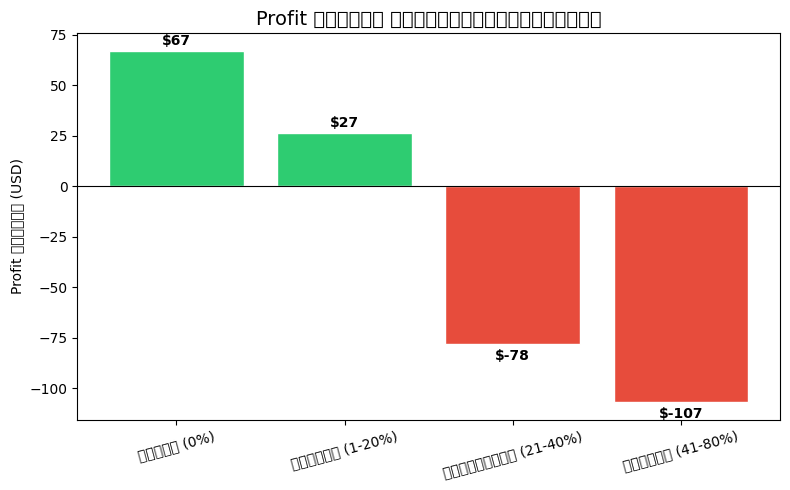

In [ ]:
df['Discount_Group'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 0.8],
    labels=['ไม่ลด (0%)', 'ลดน้อย (1-20%)', 'ลดปานกลาง (21-40%)', 'ลดเยอะ (41-80%)'])

avg_profit_by_discount = df.groupby('Discount_Group')['Profit'].mean()

plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in avg_profit_by_discount.values]
bars = plt.bar(avg_profit_by_discount.index, avg_profit_by_discount.values,
               color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit เฉลี่ย แบ่งตามระดับส่วนลด', fontsize=14)
plt.ylabel('Profit เฉลี่ย (USD)')
plt.xticks(rotation=15)

for bar, val in zip(bars, avg_profit_by_discount.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + (3 if val >= 0 else -8),
             f"${val:.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##สินค้าหมวดไหนกำไร / ขาดทุน?


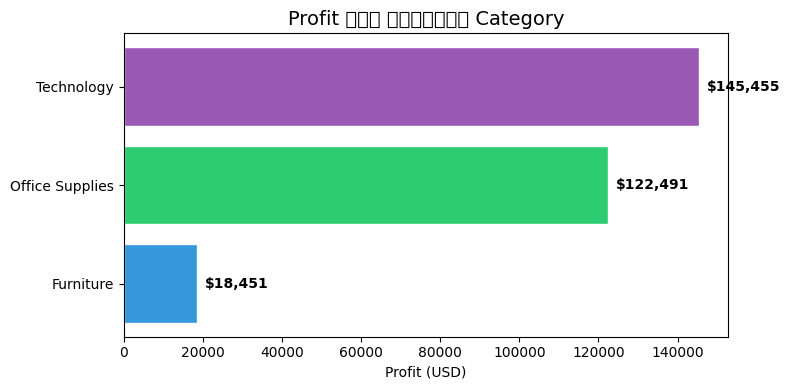

In [ ]:
cat_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(8, 4))
bars = plt.barh(cat_profit.index, cat_profit.values,
                color=['#3498db', '#2ecc71', '#9b59b6'], edgecolor='white')
plt.title('Profit รวม แบ่งตาม Category', fontsize=14)
plt.xlabel('Profit (USD)')

for bar, val in zip(bars, cat_profit.values):
    plt.text(val + 2000, bar.get_y() + bar.get_height()/2,
             f"${val:,.0f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

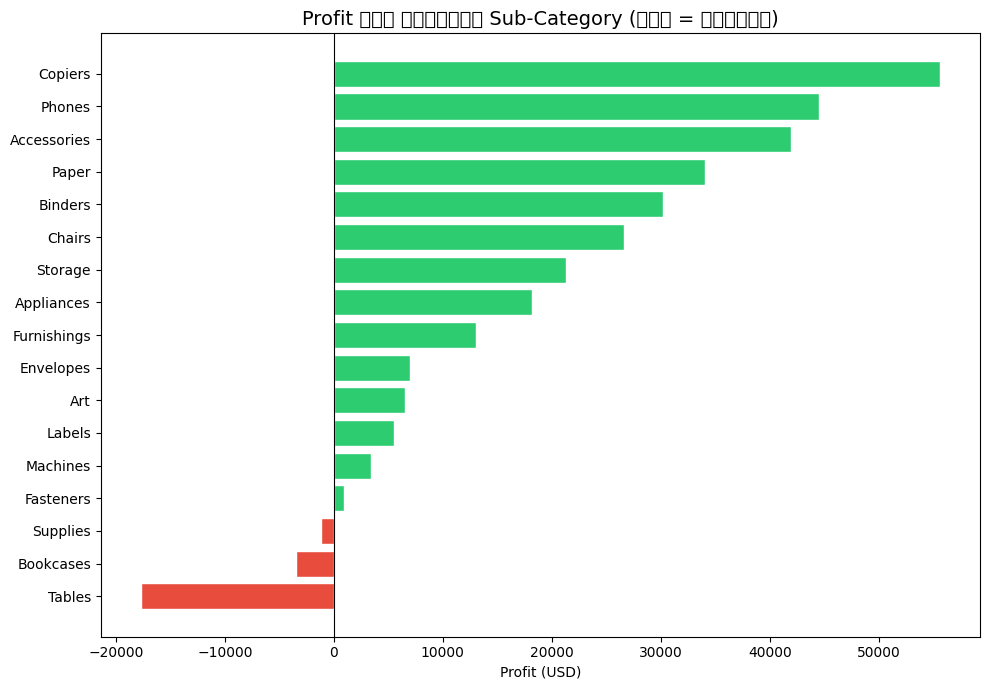

In [ ]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in sub_profit.values]

plt.figure(figsize=(10, 7))
bars = plt.barh(sub_profit.index, sub_profit.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Profit รวม แบ่งตาม Sub-Category (แดง = ขาดทุน)', fontsize=14)
plt.xlabel('Profit (USD)')

plt.tight_layout()
plt.show()

##ภูมิภาคไหนกำไรดี / ไม่ดี

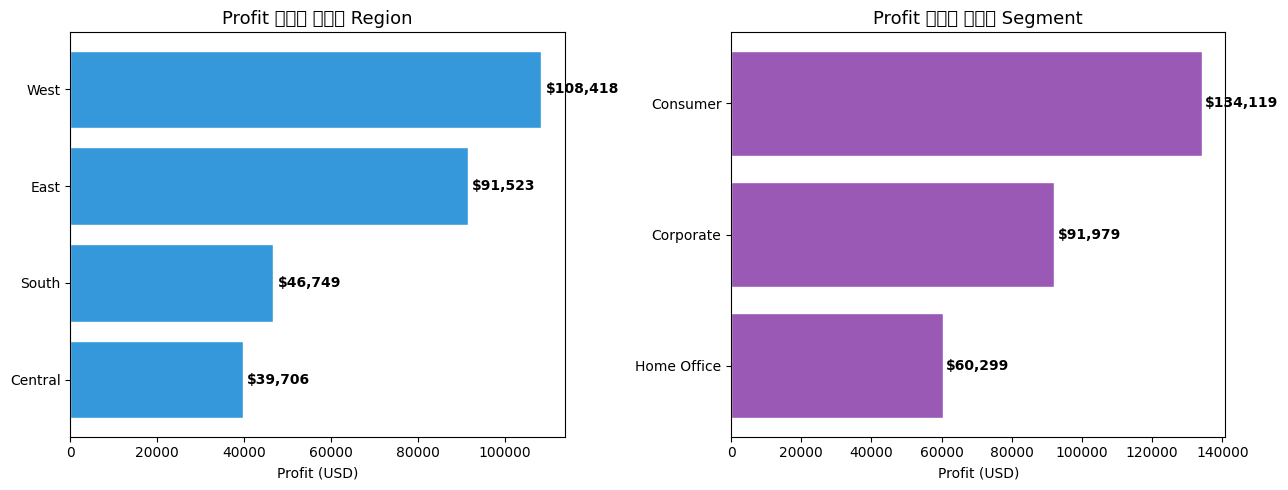

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_profit = df.groupby('Region')['Profit'].sum().sort_values()
axes[0].barh(region_profit.index, region_profit.values, color='#3498db', edgecolor='white')
axes[0].set_title('Profit รวม ตาม Region', fontsize=13)
axes[0].set_xlabel('Profit (USD)')
for i, val in enumerate(region_profit.values):
    axes[0].text(val + 1000, i, f"${val:,.0f}", va='center', fontweight='bold')

seg_profit = df.groupby('Segment')['Profit'].sum().sort_values()
axes[1].barh(seg_profit.index, seg_profit.values, color='#9b59b6', edgecolor='white')
axes[1].set_title('Profit รวม ตาม Segment', fontsize=13)
axes[1].set_xlabel('Profit (USD)')
for i, val in enumerate(seg_profit.values):
    axes[1].text(val + 1000, i, f"${val:,.0f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

x:
Ship Mode
Segment
Region
Category
Sub-Category
Sales
Quantity
Discount
y:
Profit

In [ ]:
cat_features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
num_features = ['Sales', 'Quantity', 'Discount']

X = df[cat_features + num_features]
y = df['Profit']

## แบ่งข้อมูล Train / Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {len(X_train):,} rows")
print(f"Test set:  {len(X_test):,} rows")

Train set: 7,995 rows
Test set:  1,999 rows


## ทำ Pipeline

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

## Model

In [ ]:
models = {
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train แต่ละ model + วัดผลด้วย 5-Fold Cross Validation
results = {}

for name, model in models.items():
    # สร้าง pipeline = preprocessor + model
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Cross Validation (แบ่งข้อมูล train เป็น 5 ส่วน วนทดสอบ)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')

    # Train บน train set ทั้งหมด แล้ว predict test set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # คำนวณ metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'pipeline': pipe,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'test_mae': mae,
        'test_rmse': rmse,
        'test_r2': r2,
        'y_pred': y_pred
    }

    print(f"{name}")
    print(f"   CV R² = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   Test MAE  = ${mae:.2f}")
    print(f"   Test RMSE = ${rmse:.2f}")
    print(f"   Test R²   = {r2:.4f}")

Ridge Regression
   CV R² = 0.3916 (±0.2886)
   Test MAE  = $67.76
   Test RMSE = $282.53
   Test R²   = -0.6463
Random Forest
   CV R² = 0.7212 (±0.2425)
   Test MAE  = $25.63
   Test RMSE = $229.79
   Test R²   = -0.0890
Gradient Boosting
   CV R² = 0.7663 (±0.1270)
   Test MAE  = $35.13
   Test RMSE = $206.69
   Test R²   = 0.1189


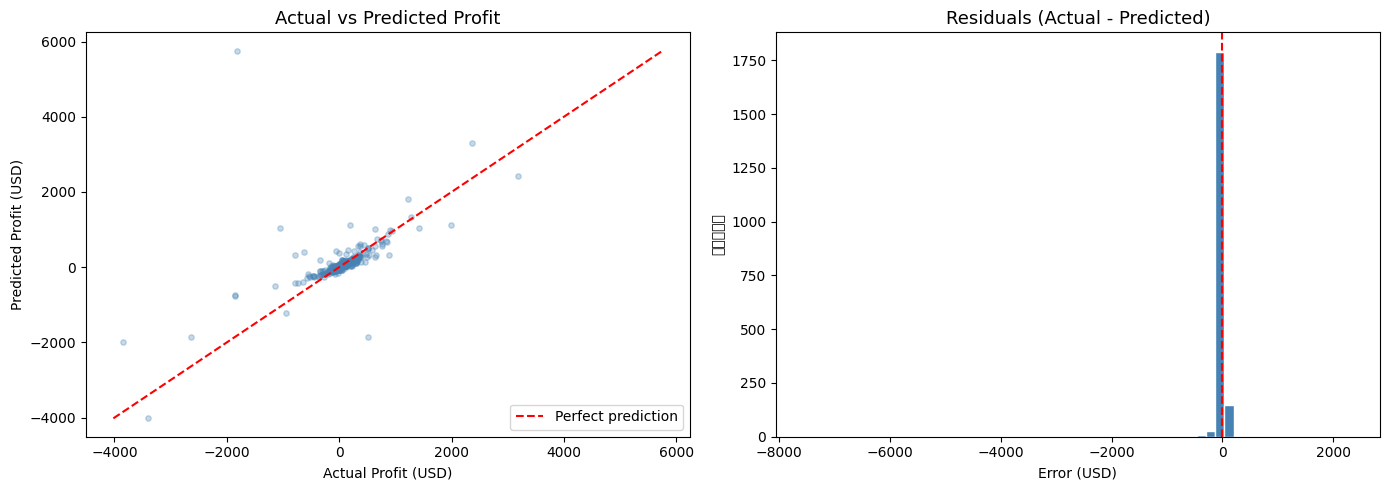

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Profit', fontsize=13)
axes[0].set_xlabel('Actual Profit (USD)')
axes[0].set_ylabel('Predicted Profit (USD)')
axes[0].legend()

residuals = y_test - y_pred
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals (Actual - Predicted)', fontsize=13)
axes[1].set_xlabel('Error (USD)')
axes[1].set_ylabel('จำนวน')

plt.tight_layout()
plt.show()